### Implementation Documentation (Cell 2)

**What this next cell does:** Resolves notebook-relative paths and creates required directories for checkpoints, metrics, and plots.

**Inputs used:** Current working directory.
**Outputs created:** `MODEL_DIR`, `FHIR_DIR`, `PROCESSED_DIR`, `CHECKPOINTS_DIR`, `VIS_DIR`, `METRICS_DIR`.

In [3]:
# Cell 2: Resolve model-relative paths and create output directories used by downstream cells.
# Outputs from this cell: MODEL_DIR, FHIR_DIR, PROCESSED_DIR, CHECKPOINTS_DIR, VIS_DIR, METRICS_DIR.
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
if cwd.name == "notebooks":
    MODEL_DIR = cwd.parent
elif cwd.name == "model":
    MODEL_DIR = cwd
else:
    MODEL_DIR = cwd / "model"

if str(MODEL_DIR) not in sys.path:
    sys.path.append(str(MODEL_DIR))

if not MODEL_DIR.exists():
    raise FileNotFoundError(f"Could not locate model directory from cwd={cwd}")

FHIR_DIR = MODEL_DIR / "fhir"
PROCESSED_DIR = MODEL_DIR / "processed_tensors"
CHECKPOINTS_DIR = MODEL_DIR / "checkpoints"
ARTIFACTS_DIR = MODEL_DIR / "training_artifacts"
VIS_DIR = ARTIFACTS_DIR / "visualizations"
METRICS_DIR = ARTIFACTS_DIR / "metrics"

for p in [CHECKPOINTS_DIR, VIS_DIR, METRICS_DIR, PROCESSED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Model directory:", MODEL_DIR)
print("FHIR directory:", FHIR_DIR)
print("Processed tensor directory:", PROCESSED_DIR)
print("Visualization output directory:", VIS_DIR)
print("Metrics output directory:", METRICS_DIR)

Model directory: /home/satwik/dev/digital-twin/model
FHIR directory: /home/satwik/dev/digital-twin/model/fhir
Processed tensor directory: /home/satwik/dev/digital-twin/model/processed_tensors
Visualization output directory: /home/satwik/dev/digital-twin/model/training_artifacts/visualizations
Metrics output directory: /home/satwik/dev/digital-twin/model/training_artifacts/metrics


### Implementation Documentation (Cell 4)

**What this next cell does:** Imports libraries/modules, sets deterministic seeds, and defines all training hyperparameters.

**Why it matters:** This is the single control point for runtime scale, speed, and reproducibility.

In [4]:
# Cell 4: Import training dependencies and define reproducible run configuration.
# This cell sets seeds and all tunable hyperparameters for the following training/evaluation cells.
import json
import random
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

try:
    from dataset_pipeline import FHIRPreprocessor, ClinicalDataset
    from trajectory_transformer import TimeAwareTransformer, QuantileLoss, get_device
    from model_evaluation import calculate_metrics, plot_learning_curve, plot_trajectory_prediction
except ModuleNotFoundError:
    from model.dataset_pipeline import FHIRPreprocessor, ClinicalDataset
    from model.trajectory_transformer import TimeAwareTransformer, QuantileLoss, get_device
    from model.model_evaluation import calculate_metrics, plot_learning_curve, plot_trajectory_prediction

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Training controls (adjust as needed)
MAX_DATASET_SAMPLES = 20000   # set to None for full dataset
BATCH_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3
OUTPUT_HORIZON = 5
MAX_TRAIN_BATCHES_PER_EPOCH = 200   # set to None for full epoch
MAX_VAL_BATCHES = 50                # set to None for full validation

# Optional: generate missing .pt files recursively from nested FHIR JSONs
CREATE_MISSING_TENSORS = False
PREPROCESS_LIMIT = 500

### Implementation Documentation (Cell 6)

**What this next cell does:** Recursively scans nested FHIR JSON files and existing `.pt` tensors, then optionally creates missing tensors.

**Why it matters:** Verifies data readiness before dataset loading and avoids training failures due to missing tensors.

In [5]:
# Cell 6: Inspect available FHIR JSON and processed tensor counts.
# Optional branch: tensorize missing JSON records into PROCESSED_DIR before training.
def list_fhir_jsons(root: Path):
    return [
        p for p in root.rglob("*.json")
        if ":Zone.Identifier" not in p.name
    ]

fhir_files = list_fhir_jsons(FHIR_DIR)
pt_files = list(PROCESSED_DIR.glob("*.pt"))

print(f"FHIR JSON files found: {len(fhir_files):,}")
print(f"Processed tensors found: {len(pt_files):,}")

if CREATE_MISSING_TENSORS:
    preprocessor = FHIRPreprocessor(sequence_length=60)
    existing_ids = {p.stem for p in pt_files}
    missing = [p for p in fhir_files if p.stem not in existing_ids]
    if PREPROCESS_LIMIT is not None:
        missing = missing[:PREPROCESS_LIMIT]

    print(f"Missing tensors to create: {len(missing):,}")
    for fp in tqdm(missing, desc="Tensorizing FHIR"):
        try:
            patient_id, static_t, temporal_t = preprocessor.parse_and_align(str(fp))
            torch.save({"static": static_t, "temporal": temporal_t}, PROCESSED_DIR / f"{patient_id}.pt")
        except Exception:
            continue

    pt_files = list(PROCESSED_DIR.glob("*.pt"))
    print(f"Processed tensors after generation: {len(pt_files):,}")

FHIR JSON files found: 129,218
Processed tensors found: 129,218


### Implementation Documentation (Cell 8)

**What this next cell does:** Builds train/validation subsets and dataloaders from tensor files, then infers feature dimensions for model construction.

**Outputs created:** `train_loader`, `val_loader`, `STATIC_DIM`, `TEMPORAL_DIM`, `NUM_BIOMARKERS`.

In [6]:
# Cell 8: Build train/validation datasets and loaders from preprocessed tensors.
# Also infers model input dimensions (STATIC_DIM, TEMPORAL_DIM) and target biomarker count.
dataset = ClinicalDataset(str(PROCESSED_DIR))
dataset_size = len(dataset)
if dataset_size < 2:
    raise RuntimeError(f"Need at least 2 tensor files to train/validate. Found {dataset_size}.")

indices = np.arange(dataset_size)
np.random.shuffle(indices)

if MAX_DATASET_SAMPLES is not None and MAX_DATASET_SAMPLES < dataset_size:
    indices = indices[:MAX_DATASET_SAMPLES]

subset_size = len(indices)
train_size = int(0.9 * subset_size)
train_size = max(1, train_size)
val_size = subset_size - train_size
if val_size == 0:
    val_size = 1
    train_size = subset_size - 1

train_indices = indices[:train_size].tolist()
val_indices = indices[train_size:train_size + val_size].tolist()

train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sample_static, sample_temporal = dataset[train_indices[0]]
STATIC_DIM = sample_static.shape[-1]
TEMPORAL_DIM = sample_temporal.shape[-1]
NUM_BIOMARKERS = TEMPORAL_DIM - 2

print(f"Total available tensors: {dataset_size:,}")
print(f"Subset used in this run: {subset_size:,}")
print(f"Train size: {len(train_dataset):,}, Validation size: {len(val_dataset):,}")
print(f"static_dim={STATIC_DIM}, temporal_dim={TEMPORAL_DIM}, num_biomarkers={NUM_BIOMARKERS}")

Total available tensors: 129,218
Subset used in this run: 20,000
Train size: 18,000, Validation size: 2,000
static_dim=2, temporal_dim=14, num_biomarkers=12


### Implementation Documentation (Cell 10)

**What this next cell does:** Selects device and initializes model, quantile loss, and optimizer.

**Why it matters:** Defines the trainable architecture and objective used by the training loop.

In [7]:
# Cell 10: Initialize hardware context, model architecture, loss function, and optimizer.
# This creates the trainable TimeAwareTransformer instance used in Cell 12.
device = get_device()
print("Using device:", device)

model = TimeAwareTransformer(
    static_dim=STATIC_DIM,
    temporal_dim=TEMPORAL_DIM,
    output_horizon=OUTPUT_HORIZON
).to(device)

criterion = QuantileLoss([0.1, 0.5, 0.9])
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

Using device: cpu
TimeAwareTransformer(
  (input_projection): Linear(in_features=14, out_features=128, bias=True)
  (static_projection): Linear(in_features=2, out_features=128, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (regressor): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1

### Implementation Documentation (Cell 12)

**What this next cell does:** Runs full epoch-based training/validation, tracks losses, and persists checkpoint + history JSON.

**Artifacts produced:** `checkpoints/fhir_transformer_pipeline.pt`, `training_artifacts/metrics/train_history.json`.

In [8]:
# Cell 12: Execute end-to-end training and validation loops.
# Per epoch: forward pass -> quantile loss -> backprop -> optimizer step -> validation pass.
# Final outputs from this cell: model checkpoint (.pt) and loss history JSON.
def make_targets(temporal_batch: torch.Tensor, horizon: int, n_biomarkers: int) -> torch.Tensor:
    # Supervised target from trailing observed biomarker windows
    return temporal_batch[:, -horizon:, :n_biomarkers]

train_losses, val_losses = [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_train = 0.0
    train_steps = 0

    for step, (static_x, temporal_x) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [train]")):
        if MAX_TRAIN_BATCHES_PER_EPOCH is not None and step >= MAX_TRAIN_BATCHES_PER_EPOCH:
            break

        static_x = static_x.to(device)
        temporal_x = temporal_x.to(device)

        optimizer.zero_grad()
        preds = model(static_x, temporal_x)
        targets = make_targets(temporal_x, OUTPUT_HORIZON, NUM_BIOMARKERS)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        running_train += loss.item()
        train_steps += 1

    avg_train = running_train / max(train_steps, 1)
    train_losses.append(avg_train)

    model.eval()
    running_val = 0.0
    val_steps = 0
    with torch.no_grad():
        for step, (static_x, temporal_x) in enumerate(tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [val]")):
            if MAX_VAL_BATCHES is not None and step >= MAX_VAL_BATCHES:
                break

            static_x = static_x.to(device)
            temporal_x = temporal_x.to(device)
            preds = model(static_x, temporal_x)
            targets = make_targets(temporal_x, OUTPUT_HORIZON, NUM_BIOMARKERS)
            vloss = criterion(preds, targets)

            running_val += vloss.item()
            val_steps += 1

    avg_val = running_val / max(val_steps, 1)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1}: train_loss={avg_train:.6f}, val_loss={avg_val:.6f}")

checkpoint_path = CHECKPOINTS_DIR / "fhir_transformer_pipeline.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "static_dim": STATIC_DIM,
    "temporal_dim": TEMPORAL_DIM,
    "output_horizon": OUTPUT_HORIZON,
    "num_biomarkers": NUM_BIOMARKERS
}, checkpoint_path)

history_path = METRICS_DIR / "train_history.json"
with open(history_path, "w") as f:
    json.dump({"train_losses": train_losses, "val_losses": val_losses}, f, indent=2)

print("Checkpoint saved to:", checkpoint_path)
print("History saved to:", history_path)

Epoch 1/5 [val]: 100%|██████████| 32/32 [00:03<00:00, 10.01it/s]


Epoch 1: train_loss=37.514263, val_loss=0.452257


Epoch 2/5 [val]: 100%|██████████| 32/32 [00:01<00:00, 16.58it/s]


Epoch 2: train_loss=0.192061, val_loss=0.796272


Epoch 3/5 [val]: 100%|██████████| 32/32 [00:01<00:00, 16.91it/s]


Epoch 3: train_loss=0.168861, val_loss=0.582669


Epoch 4/5 [val]: 100%|██████████| 32/32 [00:01<00:00, 17.06it/s]


Epoch 4: train_loss=0.159669, val_loss=0.357255


Epoch 5/5 [val]: 100%|██████████| 32/32 [00:02<00:00, 14.72it/s]

Epoch 5: train_loss=0.162088, val_loss=0.534161
Checkpoint saved to: /home/satwik/dev/digital-twin/model/checkpoints/fhir_transformer_pipeline.pt
History saved to: /home/satwik/dev/digital-twin/model/training_artifacts/metrics/train_history.json


### Implementation Documentation (Cell 14)

**What this next cell does:** Executes post-training evaluation on validation data, computes MAE/MSE, and saves visualization PNGs.

**Artifacts produced:** `training_artifacts/visualizations/*.png`, `training_artifacts/metrics/evaluation_metrics.json`.

In [9]:
# Cell 14: Run post-training evaluation on validation data and generate visual artifacts.
# This computes MAE/MSE for one selected biomarker, writes evaluation JSON, and saves PNG plots.
preprocessor = FHIRPreprocessor(sequence_length=60)
metric_order = preprocessor.metric_order

biomarker_name = "ldl_cholesterol" if "ldl_cholesterol" in metric_order else metric_order[0]
biomarker_idx = metric_order.index(biomarker_name)

model.eval()
with torch.no_grad():
    s_val, t_val = next(iter(val_loader))
    s_val = s_val.to(device)
    t_val = t_val.to(device)
    preds = model(s_val, t_val)

pred_median = preds[0, :, biomarker_idx, 1].detach().cpu().numpy()
pred_10th = preds[0, :, biomarker_idx, 0].detach().cpu().numpy()
pred_90th = preds[0, :, biomarker_idx, 2].detach().cpu().numpy()
actual = t_val[0, -OUTPUT_HORIZON:, biomarker_idx].detach().cpu().numpy()
time_steps = list(range(OUTPUT_HORIZON))

mse, mae = calculate_metrics(actual, pred_median)

learning_curve_path = VIS_DIR / "learning_curve.png"
trajectory_plot_path = VIS_DIR / "trajectory_prediction.png"

plot_learning_curve(train_losses, val_losses, filepath=str(learning_curve_path))
plot_trajectory_prediction(
    time_steps=time_steps,
    actual_labs=actual,
    pred_median=pred_median,
    pred_10th=pred_10th,
    pred_90th=pred_90th,
    filepath=str(trajectory_plot_path)
)

eval_metrics = {
    "biomarker": biomarker_name,
    "mse": float(mse),
    "mae": float(mae),
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "subset_size": len(train_dataset) + len(val_dataset)
}

eval_metrics_path = METRICS_DIR / "evaluation_metrics.json"
with open(eval_metrics_path, "w") as f:
    json.dump(eval_metrics, f, indent=2)

print("Evaluation metrics saved to:", eval_metrics_path)
print("Visualizations saved to:", VIS_DIR)
eval_metrics

         Model Evaluation Metrics
Mean Squared Error (MSE): 0.4852
Mean Absolute Error (MAE) : 0.6961
[*] Learning curve saved successfully to: /home/satwik/dev/digital-twin/model/training_artifacts/visualizations/learning_curve.png
[*] Trajectory prediction plot saved successfully to: /home/satwik/dev/digital-twin/model/training_artifacts/visualizations/trajectory_prediction.png
Evaluation metrics saved to: /home/satwik/dev/digital-twin/model/training_artifacts/metrics/evaluation_metrics.json
Visualizations saved to: /home/satwik/dev/digital-twin/model/training_artifacts/visualizations


{'biomarker': 'ldl_cholesterol',
 'mse': 0.4852316379547119,
 'mae': 0.6961334347724915,
 'epochs': 5,
 'batch_size': 64,
 'learning_rate': 0.001,
 'subset_size': 20000}

### Implementation Documentation (Cell 16)

**What this next cell does:** Lists generated artifact files and renders the saved plots inline for quick inspection.

**Result:** Confirms output paths and visual quality without leaving the notebook.

Visualization directory: /home/satwik/dev/digital-twin/model/training_artifacts/visualizations
Metrics directory: /home/satwik/dev/digital-twin/model/training_artifacts/metrics
- /home/satwik/dev/digital-twin/model/training_artifacts/visualizations/learning_curve.png
- /home/satwik/dev/digital-twin/model/training_artifacts/visualizations/trajectory_prediction.png
- /home/satwik/dev/digital-twin/model/training_artifacts/metrics/evaluation_metrics.json
- /home/satwik/dev/digital-twin/model/training_artifacts/metrics/train_history.json


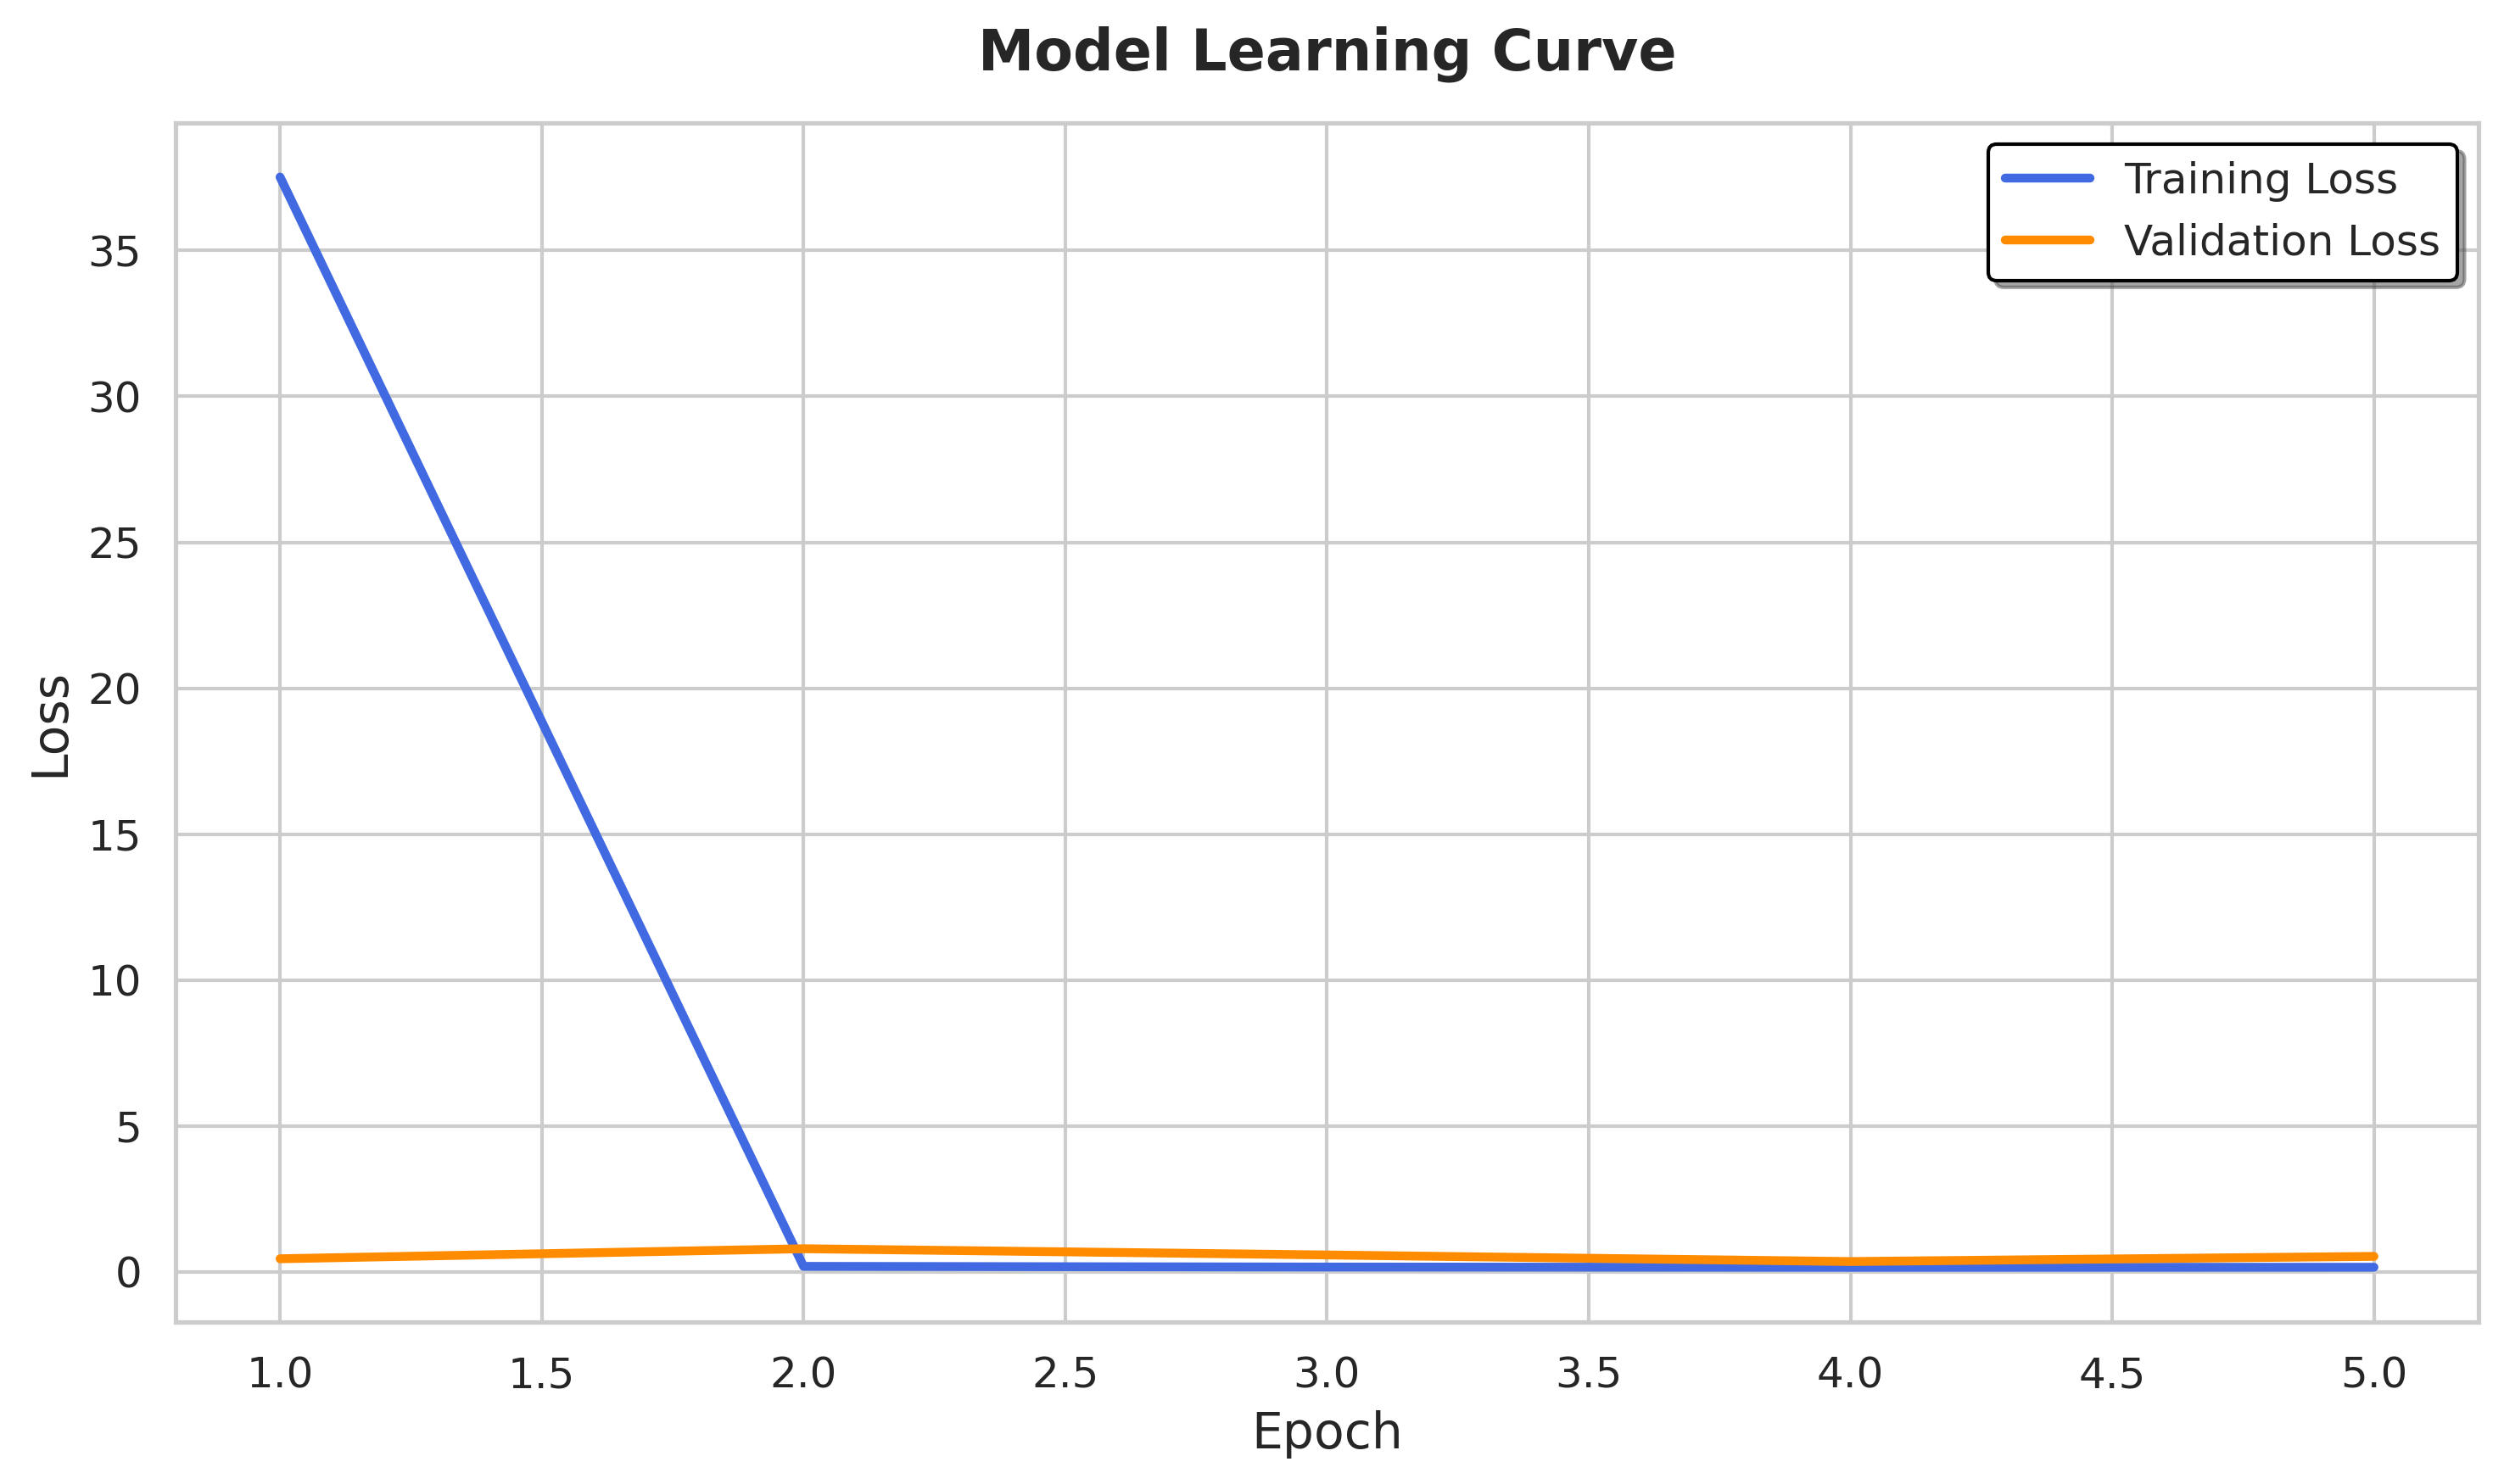

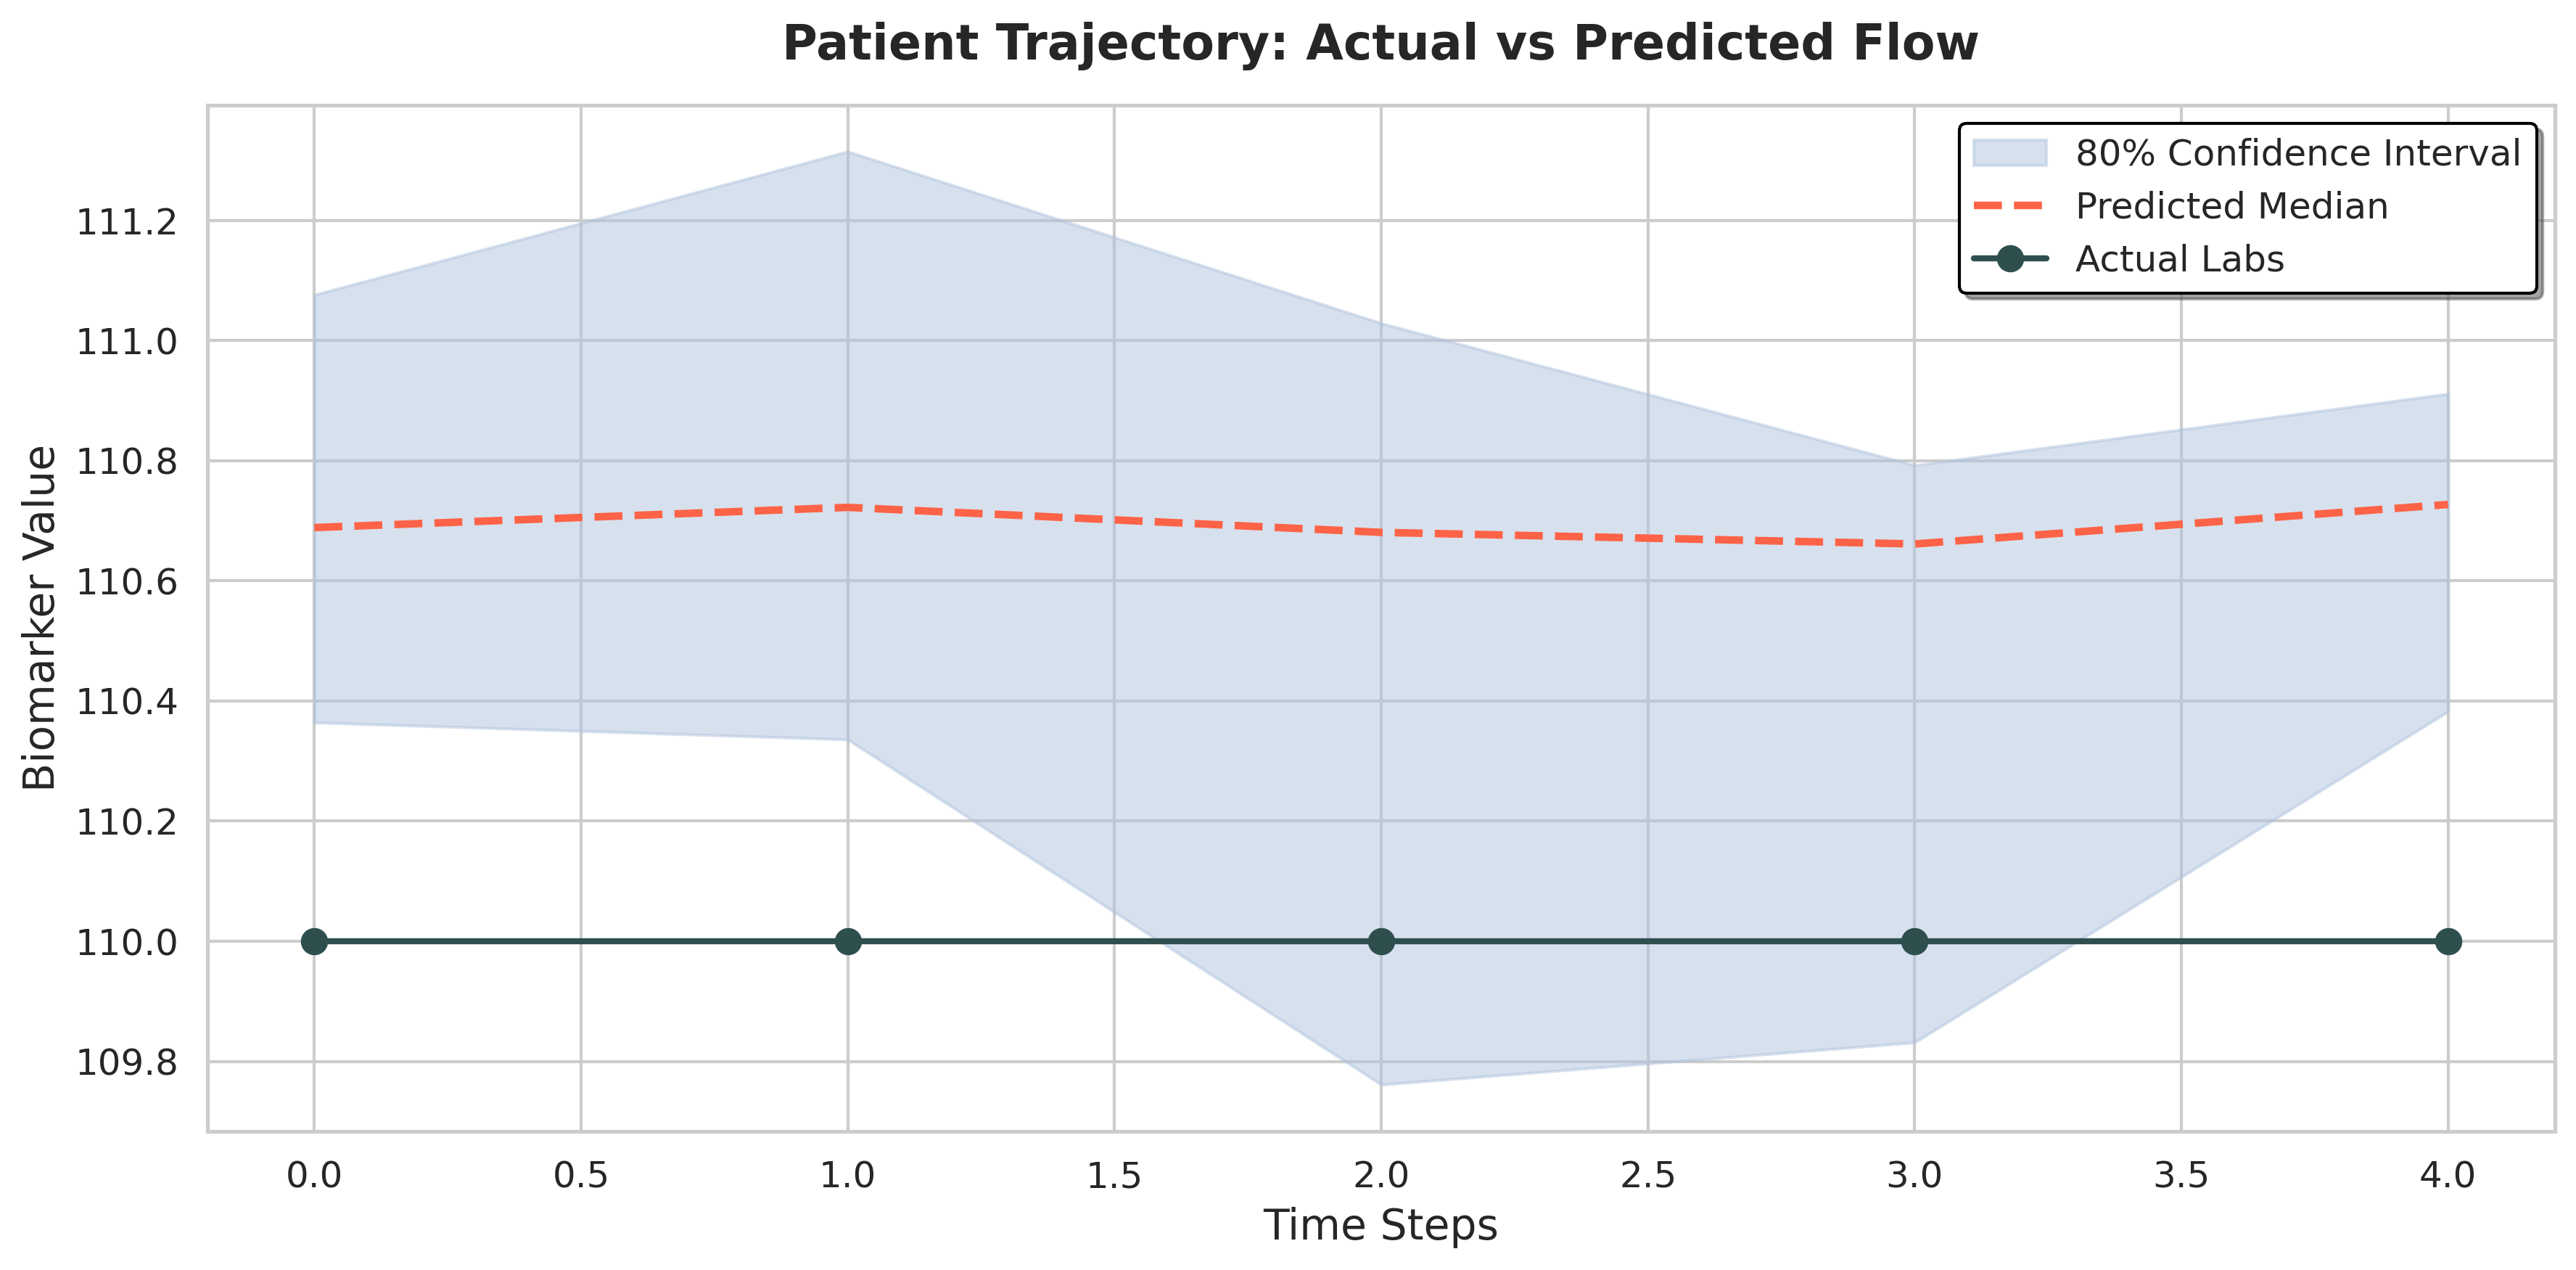

In [10]:
# Cell 16: Display generated artifacts directly in the notebook for quick review.
# This prints all artifact file paths and renders the two main PNG outputs inline.
from IPython.display import Image, display

print("Visualization directory:", VIS_DIR)
print("Metrics directory:", METRICS_DIR)

for f in sorted(VIS_DIR.glob("*.png")):
    print("-", f)

for f in sorted(METRICS_DIR.glob("*.json")):
    print("-", f)

display(Image(filename=str(VIS_DIR / "learning_curve.png")))
display(Image(filename=str(VIS_DIR / "trajectory_prediction.png")))

### Implementation Documentation (Cell 18)

**What this next cell does:** Captures runtime guidance, expected behavior, and recommended execution order for repeatable training runs.

**Why it matters:** Makes the notebook maintainable for future experiments and team handoff.

## Notes and Cell Execution Expectations

- Cell 2 should complete quickly and create required directories if missing.
- Cell 4 defines all runtime knobs; edit this cell first if you want a different training regime.
- Cell 6 is where you decide whether to preprocess missing tensors from nested FHIR JSON files.
- Cell 8 determines the effective train/validation split and feature dimensions.
- Cell 12 is the main runtime-heavy training cell.
- Cell 14 creates evaluation metrics and the visualizers in `training_artifacts` folders.
- Cell 16 verifies saved outputs and renders the generated plots inline.

### Recommended order
Run Cells 2, 4, 6, 8, 10, 12, 14, and 16 sequentially for a complete training and evaluation pass.